# Detecção de áreas queimadas — Random Forest com LOSO + features brutas

**Versão 2 do experimento.** Diagnosticamos no v1 que a máscara fornecida é
gerada por threshold de 0,065 sobre o (d)NBR. Isso fazia o RF, treinado com
`dNBR` como única feature, alcançar 100% trivialmente — apenas reaprendia a
regra geradora. Esta versão corrige o desenho experimental sem mudar o
classificador.

## O que muda em relação ao v1

| Dimensão | v2 |
|---|---|
| Cenas | **3 cenas com LOSO** |
| Features | **9 brutas/diferenças** (`B4/B5/B7` pré, pós e Δ) |
| Ground truth | **interseção** (máscara NBR ∧ máscara NDVI) |
| Validação | **Leave-One-Scene-Out** (3 folds) |
| Tuning | **`GroupKFold` por cena** |
| Métricas | **média ± desvio** entre folds |
| Baseline | **`dNBR > 0,065`** (real) + `0,27` (referência) |

## Por que estas escolhas reduzem o vazamento

A máscara é uma função simples de `dNBR` (e provavelmente de `dNDVI` pelo
nome do arquivo). Removendo `dNBR` e `dNDVI` do conjunto de features e
exigindo a concordância das duas máscaras como ground truth, o modelo
precisa aprender uma combinação **não-trivial** de bandas brutas para
chegar lá. Não elimina o vazamento por completo — bandas brutas determinam
os índices —, mas torna a tarefa não-degenerada.

LOSO entre 3 cenas, com `GroupKFold` no tuning interno, mede generalização
entre cenas em todos os pontos onde antes mediríamos memorização espacial.

## O que continua igual

Random Forest, seed `42`, métricas (Accuracy / Precision / Recall / F1 / κ /
ROC-AUC), `class_weight="balanced"`, `oob_score=True` no refit final.

## Dependências

In [1]:
!pip install numpy matplotlib rasterio scikit-learn

## 1. Imports, logger e seed

Mesma estrutura do v1, com adição de `GroupKFold` (para tuning entre cenas)
e `permutation_importance` (para checar quais features o RF realmente usa).

In [1]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("rf_burn_v2")

RNG_SEED = 42
np.random.seed(RNG_SEED)

# Ordem fixa das 9 features (importante para reportar feature_importance)
FEATURE_NAMES = [
    "B4_pre",  "B5_pre",  "B7_pre",
    "B4_post", "B5_post", "B7_post",
    "dB4",     "dB5",     "dB7",
]
N_FEATURES = len(FEATURE_NAMES)

## 2. Configuração das três cenas

Cada cena Landsat agora contribui com **9 rasters de banda** (B4, B5 e B7,
pré e pós-fogo) e **2 máscaras** (uma derivada do NBR, outra do NDVI). O
campo `dnbr_precomputed` aponta para o `dif_nbr_pre_pos.tif` que já vem com
o pacote — usamos apenas para o **baseline** (não como feature).

In [3]:
@dataclass(frozen=True)
class LandsatScene:
    """Descritor de uma cena: rasters de banda, máscaras e dNBR pré-calculado."""
    tag: str
    # Bandas Surface Reflectance pré-fogo
    b4_pre:  Path
    b5_pre:  Path
    b7_pre:  Path
    # Bandas pós-fogo
    b4_post: Path
    b5_post: Path
    b7_post: Path
    # Máscaras paralelas (interseção é o nosso ground truth)
    mask_nbr:  Path
    mask_ndvi: Path
    # dNBR já pronto — APENAS para o baseline, NÃO entra no modelo
    dnbr_precomputed: Path


SCENE_220 = LandsatScene(
    tag="220_075",
    b4_pre =Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B4.tif"),
    b5_pre =Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B5.tif"),
    b7_pre =Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B7.tif"),
    b4_post=Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B4.tif"),
    b5_post=Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B5.tif"),
    b7_post=Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B7.tif"),
    mask_nbr =Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
    mask_ndvi=Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_ndvi.tif"),
    dnbr_precomputed=Path("220_075/diferenca_pre_pos/LC08_220075_dif_nbr_pre_pos.tif"),
)

SCENE_221 = LandsatScene(
    tag="221_074",
    b4_pre =Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B4.tif"),
    b5_pre =Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B5.tif"),
    b7_pre =Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B7.tif"),
    b4_post=Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B4.tif"),
    b5_post=Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B5.tif"),
    b7_post=Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B7.tif"),
    mask_nbr =Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
    mask_ndvi=Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_ndvi.tif"),
    dnbr_precomputed=Path("221_074/diferenca_pre_pos/LC09_221074_dif_nbr_pre_pos.tif"),
)

SCENE_222 = LandsatScene(
    tag="222_074",
    b4_pre =Path("222_074/img_pre/LC08_L2SP_222074_20240819_20240823_02_T1_SR_B4.tif"),
    b5_pre =Path("222_074/img_pre/LC08_L2SP_222074_20240819_20240823_02_T1_SR_B5.tif"),
    b7_pre =Path("222_074/img_pre/LC08_L2SP_222074_20240819_20240823_02_T1_SR_B7.tif"),
    b4_post=Path("222_074/img_pos/LC09_L2SP_222074_20240827_20240828_02_T1_SR_B4.tif"),
    b5_post=Path("222_074/img_pos/LC09_L2SP_222074_20240827_20240828_02_T1_SR_B5.tif"),
    b7_post=Path("222_074/img_pos/LC09_L2SP_222074_20240827_20240828_02_T1_SR_B7.tif"),
    mask_nbr =Path("222_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
    mask_ndvi=Path("222_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_ndvi.tif"),
    dnbr_precomputed=Path("222_074/diferenca_pre_pos/LC09_222074_dif_nbr_pre_pos.tif"),
)

ALL_SCENES: list[LandsatScene] = [SCENE_220, SCENE_221, SCENE_222]

OUT_DIR = Path("./saida_modelo_rf_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

log.info("Cenas configuradas: %s", [s.tag for s in ALL_SCENES])
log.info("Diretório de saída: %s", OUT_DIR)

16:04:17 [INFO] Cenas configuradas: ['220_075', '221_074', '222_074']
16:04:17 [INFO] Diretório de saída: saida_modelo_rf_v2


## 3. I/O raster — agora com nearest neighbor para máscaras

Duas funções de reprojeção, porque o tipo do dado importa:

- **Bandas e índices contínuos** (B4, B5, B7, dNBR): reamostragem **bilinear**.
  É a interpolação adequada para valores contínuos.
- **Máscaras binárias** (NBR e NDVI): reamostragem **nearest neighbor**.
  Bilinear introduziria valores 0,5 que descaracterizam a classe.

A máscara NBR de cada cena é adotada como **grid de referência**. Bandas e a
máscara NDVI são reamostradas para esse grid.

In [4]:
def warp_continuous(src_path: Path, ref_path: Path) -> np.ndarray:
    """Reamostra um raster contínuo para o grid de `ref_path` (bilinear)."""
    with rasterio.open(ref_path) as ref:
        out_shape, out_transform, out_crs = ref.shape, ref.transform, ref.crs

    out = np.full(out_shape, np.nan, dtype=np.float32)
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=out_transform,
            dst_crs=out_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
    return out


def warp_categorical(src_path: Path, ref_path: Path) -> np.ndarray:
    """Reamostra uma máscara binária para o grid de `ref_path` (nearest)."""
    with rasterio.open(ref_path) as ref:
        out_shape, out_transform, out_crs = ref.shape, ref.transform, ref.crs

    out = np.full(out_shape, np.nan, dtype=np.float32)
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=out_transform,
            dst_crs=out_crs,
            resampling=Resampling.nearest,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
    return out


def to_truth_codes(arr: np.ndarray) -> np.ndarray:
    """Converte raster bruto em int8: 0 = não queimada, 1 = queimada, -1 = inválido."""
    out = np.full(arr.shape, -1, dtype=np.int8)
    out[arr == 0] = 0
    out[arr == 1] = 1
    return out

## 4. Construção do dataset por cena

Para cada cena, esta etapa:

1. Lê as **duas máscaras**, alinha a NDVI ao grid da NBR (nearest), e
   computa a **interseção**: pixel é "queimada" só se *as duas* máscaras
   concordam. Onde qualquer das duas é inválida, marcamos `-1`.
2. Lê e alinha as **6 bandas** (B4/B5/B7 × pré/pós) ao grid da NBR.
3. Calcula as **3 diferenças** (`dB4`, `dB5`, `dB7`).
4. Empilha as 9 features em um cubo `(H, W, 9)` e vetoriza.
5. Lê o **dNBR pré-calculado** apenas para o baseline — NÃO entra no
   conjunto de features.
6. Filtra pixels válidos (sem NaN em nenhuma feature, máscara ≠ -1).
7. Subamostra estratificado para `MAX_PIXELS_PER_SCENE` pixels, evitando
   estouro de memória ao manter as três cenas carregadas em paralelo.

In [5]:
MAX_PIXELS_PER_SCENE = 2_000_000   # após filtragem de inválidos


def build_dataset(scene: LandsatScene) -> dict:
    """Constrói (X, y, dnbr_baseline) para uma cena, com subamostragem estratificada.

    Retorna um dict com:
      X        : (N, 9) float32  — features brutas + diferenças
      y        : (N,)   int8     — 0/1 da máscara interseção
      dnbr_b   : (N,)   float32  — dNBR pré-calculado, alinhado, mesmos N pixels
                                    (apenas para baseline)
      counts   : dict de estatísticas
    """
    log.info("[%s] lendo máscaras NBR e NDVI", scene.tag)
    grid_ref = scene.mask_nbr
    m_nbr_raw  = warp_categorical(grid_ref,        grid_ref)  # leitura no próprio grid
    m_ndvi_raw = warp_categorical(scene.mask_ndvi, grid_ref)

    m_nbr  = to_truth_codes(m_nbr_raw)
    m_ndvi = to_truth_codes(m_ndvi_raw)

    # Interseção: queimada só se as duas concordam; inválido se qualquer das duas é inválida
    truth = np.full(m_nbr.shape, -1, dtype=np.int8)
    both_valid = (m_nbr >= 0) & (m_ndvi >= 0)
    truth[both_valid & (m_nbr == 1) & (m_ndvi == 1)] = 1
    truth[both_valid & ~((m_nbr == 1) & (m_ndvi == 1))] = 0

    log.info("[%s] alinhando 6 bandas ao grid da máscara", scene.tag)
    b4_pre  = warp_continuous(scene.b4_pre,  grid_ref)
    b5_pre  = warp_continuous(scene.b5_pre,  grid_ref)
    b7_pre  = warp_continuous(scene.b7_pre,  grid_ref)
    b4_post = warp_continuous(scene.b4_post, grid_ref)
    b5_post = warp_continuous(scene.b5_post, grid_ref)
    b7_post = warp_continuous(scene.b7_post, grid_ref)

    # Diferenças
    dB4 = b4_pre - b4_post
    dB5 = b5_pre - b5_post
    dB7 = b7_pre - b7_post

    # Stack na ordem fixa de FEATURE_NAMES
    cube = np.stack(
        [b4_pre, b5_pre, b7_pre,
         b4_post, b5_post, b7_post,
         dB4, dB5, dB7],
        axis=-1,
    )  # (H, W, 9)

    # dNBR pré-calculado apenas para baseline
    log.info("[%s] alinhando dNBR pré-calculado (baseline)", scene.tag)
    dnbr = warp_continuous(scene.dnbr_precomputed, grid_ref)

    # Vetoriza e filtra inválidos
    H, W, F = cube.shape
    X_flat = cube.reshape(-1, F)
    y_flat = truth.ravel()
    dnbr_flat = dnbr.ravel()

    valid = (
        (y_flat >= 0)
        & np.all(np.isfinite(X_flat), axis=1)
        & np.isfinite(dnbr_flat)
    )

    X = X_flat[valid]
    y = y_flat[valid].astype(np.int8)
    dnbr_b = dnbr_flat[valid].astype(np.float32)

    n_total = X.shape[0]
    n_burn = int(y.sum())
    log.info("[%s] pixels válidos: %d (%.2f%% queimada)",
             scene.tag, n_total, 100 * n_burn / max(n_total, 1))

    # Subamostragem estratificada (para caber 3 cenas na memória)
    if n_total > MAX_PIXELS_PER_SCENE:
        rng = np.random.default_rng(RNG_SEED + hash(scene.tag) % 1000)
        # Mantém a proporção original entre classes
        idx_burn   = np.where(y == 1)[0]
        idx_unburn = np.where(y == 0)[0]
        prop_burn  = n_burn / n_total
        n_take_burn   = int(round(MAX_PIXELS_PER_SCENE * prop_burn))
        n_take_unburn = MAX_PIXELS_PER_SCENE - n_take_burn

        sel_burn   = rng.choice(idx_burn,   size=min(n_take_burn,   len(idx_burn)),   replace=False)
        sel_unburn = rng.choice(idx_unburn, size=min(n_take_unburn, len(idx_unburn)), replace=False)
        sel = np.concatenate([sel_burn, sel_unburn])
        rng.shuffle(sel)

        X = X[sel]; y = y[sel]; dnbr_b = dnbr_b[sel]
        log.info("[%s] subamostrado para %d pixels (estratificado)", scene.tag, len(y))

    return {
        "X": X, "y": y, "dnbr_b": dnbr_b,
        "counts": {
            "n_total_valid": n_total,
            "n_after_subsample": len(y),
            "burn_ratio": float(y.mean()),
        },
    }

## 5. Carregar as três cenas

Aplica `build_dataset` para as três cenas. O dicionário `DATA` mapeia
`tag → {X, y, dnbr_b, counts}`. Esta é a etapa mais demorada do notebook —
roda uma vez e tudo o que vem depois é rápido.

In [6]:
DATA: dict[str, dict] = {}

for scene in ALL_SCENES:
    log.info("=" * 60)
    log.info("Processando cena %s", scene.tag)
    log.info("=" * 60)
    DATA[scene.tag] = build_dataset(scene)

# Sumário
print("\nSumário das cenas:")
print(f"{'cena':<10} {'válidos':>12} {'amostrados':>12} {'queimada':>10}")
print("-" * 48)
for tag, d in DATA.items():
    c = d["counts"]
    print(f"{tag:<10} {c['n_total_valid']:>12,} {c['n_after_subsample']:>12,} "
          f"{c['burn_ratio']*100:>9.2f}%")

16:05:25 [INFO] ============================================================
16:05:25 [INFO] Processando cena 220_075
16:05:25 [INFO] ============================================================
16:05:25 [INFO] [220_075] lendo máscaras NBR e NDVI
16:05:29 [INFO] [220_075] alinhando 6 bandas ao grid da máscara
16:05:41 [INFO] [220_075] alinhando dNBR pré-calculado (baseline)
16:05:45 [INFO] [220_075] pixels válidos: 40473413 (6.31% queimada)
16:05:46 [INFO] [220_075] subamostrado para 2000000 pixels (estratificado)
16:05:46 [INFO] ============================================================
16:05:46 [INFO] Processando cena 221_074
16:05:46 [INFO] ============================================================
16:05:46 [INFO] [221_074] lendo máscaras NBR e NDVI
16:05:50 [INFO] [221_074] alinhando 6 bandas ao grid da máscara
16:06:02 [INFO] [221_074] alinhando dNBR pré-calculado (baseline)
16:06:07 [INFO] [221_074] pixels válidos: 40137022 (3.68% queimada)
16:06:07 [INFO] [221_074] subamostr


Sumário das cenas:
cena            válidos   amostrados   queimada
------------------------------------------------
220_075      40,473,413    2,000,000      6.31%
221_074      40,137,022    2,000,000      3.68%
222_074      40,301,849    2,000,000      1.81%


## 6. Utilitários — predição em chunks, métricas, plots

Mesmas funções do v1, com pequenas adaptações:

- `compute_metrics`: retorna um dict (sem imprimir), para alimentar o
  agregador entre folds.
- `print_fold_report`: imprime o relatório de um fold, comparando RF contra
  o baseline `dNBR > 0,065` (threshold real do gerador).
- `plot_diagnostics`: matriz de confusão + ROC, igual ao v1.

In [7]:
def batch_predict(
    model, X: np.ndarray, *, chunk_size: int = 500_000, label: str = "predict",
) -> tuple[np.ndarray, np.ndarray]:
    """Inferência em chunks. Retorna (preds int8, prob. classe 1 float32)."""
    n = X.shape[0]
    preds = np.empty(n, dtype=np.int8)
    proba = np.empty(n, dtype=np.float32)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        sub = X[start:end]
        preds[start:end] = model.predict(sub).astype(np.int8)
        proba[start:end] = model.predict_proba(sub)[:, 1].astype(np.float32)
        log.info("%s: %d / %d (%.1f%%)", label, end, n, 100 * end / n)
    return preds, proba


def compute_metrics(y_true, y_pred, y_proba=None) -> dict[str, float]:
    """Calcula o pacote padrão de métricas e retorna como dict."""
    out = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    if y_proba is not None:
        out["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return out


def print_fold_report(
    fold_label: str,
    y_true, y_pred, y_proba,
    baseline_065_pred, baseline_027_pred,
) -> None:
    """Tabela: RF × baseline 0,065 × baseline 0,27 (Key & Benson)."""
    rf       = compute_metrics(y_true, y_pred,            y_proba)
    base_065 = compute_metrics(y_true, baseline_065_pred)
    base_027 = compute_metrics(y_true, baseline_027_pred)

    print(f"=== Fold cego: {fold_label} ===")
    print(classification_report(
        y_true, y_pred,
        target_names=["não queimada", "queimada"],
        digits=4, zero_division=0,
    ))
    print(f"{'Métrica':<10} {'baseline 0.065':>15} {'baseline 0.27':>15} {'RF':>10}")
    print("-" * 56)
    for k in ["Accuracy", "Precision", "Recall", "F1", "Kappa"]:
        print(f"{k:<10} {base_065[k]:>15.4f} {base_027[k]:>15.4f} {rf[k]:>10.4f}")
    if "ROC-AUC" in rf:
        print(f"{'ROC-AUC':<10} {'-':>15} {'-':>15} {rf['ROC-AUC']:>10.4f}")
    print()


def plot_diagnostics(y_true, y_pred, y_proba, *, panel_title: str) -> None:
    """Matriz de confusão + curva ROC."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["não queim.", "queimada"]).plot(
        ax=axes[0], cmap="Blues", values_format="d", colorbar=False,
    )
    axes[0].set_title(f"Matriz de confusão — {panel_title}")

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].set_title(f"ROC — {panel_title}")
    axes[1].legend(loc="lower right")

    plt.tight_layout(); plt.show()

## 7. Loop LOSO — Leave-One-Scene-Out

Para cada uma das três cenas, fazemos:

1. Separamos as **outras duas** como conjunto de treino, juntando suas
   amostras e marcando a cena de origem como `groups`.
2. Rodamos `GridSearchCV` com `GroupKFold(n_splits=2)` — o tuning é
   avaliado **entre cenas**, não entre amostras aleatórias da mesma cena.
3. Refitamos o melhor modelo com `oob_score=True` para uma estimativa extra.
4. Aplicamos na **cena cega** e calculamos métricas.
5. Comparamos contra dois baselines:
   - `dNBR > 0,065`: threshold real do gerador. Esse é o piso a bater.
   - `dNBR > 0,27`: referência da literatura (Key & Benson).

Espaço de busca agora inclui `max_features` ("sqrt"/"log2") porque temos 9
features. São 36 combinações × 2 folds internos × 3 folds LOSO externos.

In [8]:
rf_template = RandomForestClassifier(
    class_weight="balanced",
    random_state=RNG_SEED,
    n_jobs=-1,
    bootstrap=True,
)

search_space = {
    "n_estimators":     [300, 500],
    "max_depth":        [None, 15, 25],
    "min_samples_leaf": [1, 5, 20],
    "max_features":     ["sqrt", "log2"],
}

KB_THRESHOLD       = 0.27    # Key & Benson (referência da literatura)
GENERATOR_THRESHOLD = 0.065   # threshold real que gerou as máscaras

# Quanto subamostrar dentro do conjunto de treino LOSO (com 2 cenas, ~50k já basta)
TRAIN_BUDGET = 50_000


def loso_fold(blind_scene: LandsatScene, all_scenes: Sequence[LandsatScene]) -> dict:
    """Roda um fold LOSO: treina nas N-1 cenas, testa cego em `blind_scene`."""
    log.info("\n" + "#" * 70)
    log.info("# LOSO fold | cena cega: %s", blind_scene.tag)
    log.info("#" * 70)

    train_scenes = [s for s in all_scenes if s.tag != blind_scene.tag]

    # Concatena dados das cenas de treino + group_id por cena
    Xs, ys, gs = [], [], []
    for g_id, sc in enumerate(train_scenes):
        d = DATA[sc.tag]
        Xs.append(d["X"]); ys.append(d["y"])
        gs.append(np.full(len(d["y"]), g_id, dtype=np.int8))
    X_train_full = np.vstack(Xs)
    y_train_full = np.concatenate(ys)
    g_train_full = np.concatenate(gs)

    # Subamostragem estratificada por classe, mantendo proporção entre cenas de treino
    rng = np.random.default_rng(RNG_SEED + hash(blind_scene.tag) % 1000)
    take_per_scene = TRAIN_BUDGET // len(train_scenes)

    sel_idx = []
    for g_id in range(len(train_scenes)):
        scene_mask = (g_train_full == g_id)
        idx_burn   = np.where(scene_mask & (y_train_full == 1))[0]
        idx_unburn = np.where(scene_mask & (y_train_full == 0))[0]
        n_in_scene = scene_mask.sum()
        prop_burn  = (y_train_full[scene_mask] == 1).sum() / max(n_in_scene, 1)
        n_take_burn   = int(round(take_per_scene * prop_burn))
        n_take_unburn = take_per_scene - n_take_burn

        sel_idx.append(rng.choice(idx_burn,   size=min(n_take_burn,   len(idx_burn)),   replace=False))
        sel_idx.append(rng.choice(idx_unburn, size=min(n_take_unburn, len(idx_unburn)), replace=False))

    sel = np.concatenate(sel_idx)
    rng.shuffle(sel)

    X_train = X_train_full[sel]
    y_train = y_train_full[sel]
    g_train = g_train_full[sel]

    log.info("Treino: %d amostras (queimada=%.2f%%) — cenas: %s",
             len(y_train), 100 * y_train.mean(), [s.tag for s in train_scenes])

    # GridSearchCV com GroupKFold por cena (tuning entre cenas)
    cv_inner = GroupKFold(n_splits=len(train_scenes))
    grid = GridSearchCV(
        rf_template,
        search_space,
        scoring="f1",
        cv=cv_inner,
        n_jobs=-1,
        verbose=0,
        refit=False,
    )
    grid.fit(X_train, y_train, groups=g_train)
    log.info("Melhores hiperparâmetros: %s", grid.best_params_)
    log.info("F1 médio (CV entre cenas): %.4f", grid.best_score_)

    # Refit final com OOB
    rf_final = RandomForestClassifier(
        **grid.best_params_,
        class_weight="balanced",
        random_state=RNG_SEED,
        n_jobs=-1,
        bootstrap=True,
        oob_score=True,
    )
    rf_final.fit(X_train, y_train)
    log.info("OOB score no refit: %.4f", rf_final.oob_score_)

    # Predição na cena cega
    blind = DATA[blind_scene.tag]
    X_blind, y_blind, dnbr_blind = blind["X"], blind["y"], blind["dnbr_b"]

    pred_blind, proba_blind = batch_predict(
        rf_final, X_blind, label=f"blind {blind_scene.tag}",
    )

    # Baselines
    base_065 = (dnbr_blind > GENERATOR_THRESHOLD).astype(np.int8)
    base_027 = (dnbr_blind > KB_THRESHOLD).astype(np.int8)

    # Métricas
    rf_metrics       = compute_metrics(y_blind, pred_blind, proba_blind)
    baseline_065_met = compute_metrics(y_blind, base_065)
    baseline_027_met = compute_metrics(y_blind, base_027)

    print_fold_report(
        blind_scene.tag, y_blind, pred_blind, proba_blind, base_065, base_027,
    )

    return {
        "blind_tag":     blind_scene.tag,
        "best_params":   grid.best_params_,
        "best_cv_f1":    float(grid.best_score_),
        "oob_score":     float(rf_final.oob_score_),
        "rf_metrics":    rf_metrics,
        "base_065":      baseline_065_met,
        "base_027":      baseline_027_met,
        "feature_imp":   rf_final.feature_importances_.copy(),
        "y_blind":       y_blind,
        "pred_blind":    pred_blind,
        "proba_blind":   proba_blind,
        "X_train":       X_train,        # guardado p/ permutation_importance depois
        "y_train":       y_train,
        "rf_final":      rf_final,
    }


# --- Executa os 3 folds ---------------------------------------------------
loso_results: list[dict] = []
for blind in ALL_SCENES:
    loso_results.append(loso_fold(blind, ALL_SCENES))

16:07:07 [INFO] 
######################################################################
16:07:07 [INFO] # LOSO fold | cena cega: 220_075
16:07:07 [INFO] ######################################################################
16:07:07 [INFO] Treino: 50000 amostras (queimada=2.74%) — cenas: ['221_074', '222_074']
16:09:45 [INFO] Melhores hiperparâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
16:09:45 [INFO] F1 médio (CV entre cenas): 0.8959
16:09:53 [INFO] OOB score no refit: 0.9962
16:09:56 [INFO] blind 220_075: 500000 / 2000000 (25.0%)
16:10:00 [INFO] blind 220_075: 1000000 / 2000000 (50.0%)
16:10:03 [INFO] blind 220_075: 1500000 / 2000000 (75.0%)
16:10:07 [INFO] blind 220_075: 2000000 / 2000000 (100.0%)


=== Fold cego: 220_075 ===


16:10:11 [INFO] 
######################################################################
16:10:11 [INFO] # LOSO fold | cena cega: 221_074
16:10:11 [INFO] ######################################################################
16:10:11 [INFO] Treino: 50000 amostras (queimada=4.06%) — cenas: ['220_075', '222_074']


              precision    recall  f1-score   support

não queimada     0.9952    0.9968    0.9960   1873718
    queimada     0.9517    0.9281    0.9397    126282

    accuracy                         0.9925   2000000
   macro avg     0.9734    0.9625    0.9679   2000000
weighted avg     0.9924    0.9925    0.9924   2000000

Métrica     baseline 0.065   baseline 0.27         RF
--------------------------------------------------------
Accuracy            0.9843          0.9429     0.9925
Precision           0.8011          0.9997     0.9517
Recall              1.0000          0.0952     0.9281
F1                  0.8896          0.1738     0.9397
Kappa               0.8812          0.1646     0.9357
ROC-AUC                  -               -     0.9992



16:13:02 [INFO] Melhores hiperparâmetros: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
16:13:02 [INFO] F1 médio (CV entre cenas): 0.9143
16:13:10 [INFO] OOB score no refit: 0.9960
16:13:13 [INFO] blind 221_074: 500000 / 2000000 (25.0%)
16:13:16 [INFO] blind 221_074: 1000000 / 2000000 (50.0%)
16:13:20 [INFO] blind 221_074: 1500000 / 2000000 (75.0%)
16:13:23 [INFO] blind 221_074: 2000000 / 2000000 (100.0%)


=== Fold cego: 221_074 ===


16:13:28 [INFO] 
######################################################################
16:13:28 [INFO] # LOSO fold | cena cega: 222_074
16:13:28 [INFO] ######################################################################
16:13:28 [INFO] Treino: 50000 amostras (queimada=5.00%) — cenas: ['220_075', '221_074']


              precision    recall  f1-score   support

não queimada     0.9968    0.9986    0.9977   1926443
    queimada     0.9616    0.9158    0.9381     73557

    accuracy                         0.9956   2000000
   macro avg     0.9792    0.9572    0.9679   2000000
weighted avg     0.9955    0.9956    0.9955   2000000

Métrica     baseline 0.065   baseline 0.27         RF
--------------------------------------------------------
Accuracy            0.9878          0.9666     0.9956
Precision           0.7513          0.9976     0.9616
Recall              1.0000          0.0911     0.9158
F1                  0.8580          0.1670     0.9381
Kappa               0.8517          0.1618     0.9358
ROC-AUC                  -               -     0.9996



16:16:30 [INFO] Melhores hiperparâmetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
16:16:30 [INFO] F1 médio (CV entre cenas): 0.9267
16:16:37 [INFO] OOB score no refit: 0.9945
16:16:41 [INFO] blind 222_074: 500000 / 2000000 (25.0%)
16:16:44 [INFO] blind 222_074: 1000000 / 2000000 (50.0%)
16:16:48 [INFO] blind 222_074: 1500000 / 2000000 (75.0%)
16:16:51 [INFO] blind 222_074: 2000000 / 2000000 (100.0%)


=== Fold cego: 222_074 ===
              precision    recall  f1-score   support

não queimada     0.9992    0.9977    0.9985   1963869
    queimada     0.8839    0.9575    0.9192     36131

    accuracy                         0.9970   2000000
   macro avg     0.9416    0.9776    0.9588   2000000
weighted avg     0.9971    0.9970    0.9970   2000000

Métrica     baseline 0.065   baseline 0.27         RF
--------------------------------------------------------
Accuracy            0.9884          0.9841     0.9970
Precision           0.6084          0.9881     0.8839
Recall              1.0000          0.1214     0.9575
F1                  0.7566          0.2162     0.9192
Kappa               0.7510          0.2131     0.9177
ROC-AUC                  -               -     0.9996



## 8. Agregação dos resultados — média ± desvio entre folds

Os três folds LOSO produzem três conjuntos de métricas. O número que
realmente importa é a **média ± desvio**: ele captura o desempenho típico
e a estabilidade entre cenas. Quanto maior o desvio, mais sensível o modelo
é à mudança de cena (sinal de overfitting às cenas específicas de treino).

In [9]:
METRIC_KEYS = ["Accuracy", "Precision", "Recall", "F1", "Kappa", "ROC-AUC"]


def aggregate(per_fold_dicts: list[dict], keys=METRIC_KEYS) -> dict[str, tuple[float, float]]:
    """Devolve {métrica: (média, desvio)} a partir de lista de dicts."""
    out = {}
    for k in keys:
        vals = np.array([d.get(k, np.nan) for d in per_fold_dicts], dtype=float)
        vals = vals[np.isfinite(vals)]
        out[k] = (float(vals.mean()), float(vals.std())) if len(vals) else (np.nan, np.nan)
    return out


rf_per_fold       = [r["rf_metrics"] for r in loso_results]
base065_per_fold  = [r["base_065"]   for r in loso_results]
base027_per_fold  = [r["base_027"]   for r in loso_results]

agg_rf       = aggregate(rf_per_fold)
agg_base_065 = aggregate(base065_per_fold,  keys=["Accuracy", "Precision", "Recall", "F1", "Kappa"])
agg_base_027 = aggregate(base027_per_fold,  keys=["Accuracy", "Precision", "Recall", "F1", "Kappa"])

# --- Tabela detalhada por fold -------------------------------------------
print("=" * 78)
print("LOSO — métricas por fold (RF)")
print("=" * 78)
print(f"{'cena cega':<10} {'F1':>8} {'Kappa':>8} {'AUC':>8} {'Acc':>8} {'Prec':>8} {'Rec':>8}  best_params")
print("-" * 78)
for r in loso_results:
    m = r["rf_metrics"]
    bp = r["best_params"]
    bp_short = f"n={bp['n_estimators']},d={bp['max_depth']},leaf={bp['min_samples_leaf']},f={bp['max_features']}"
    print(f"{r['blind_tag']:<10} "
          f"{m['F1']:>8.4f} {m['Kappa']:>8.4f} {m['ROC-AUC']:>8.4f} "
          f"{m['Accuracy']:>8.4f} {m['Precision']:>8.4f} {m['Recall']:>8.4f}  {bp_short}")

# --- Resumo agregado ------------------------------------------------------
print()
print("=" * 78)
print("LOSO — resumo agregado (média ± desvio entre 3 folds)")
print("=" * 78)
print(f"{'Métrica':<10} {'Baseline 0.065':>20} {'Baseline 0.27':>20} {'Random Forest':>20}")
print("-" * 78)
for k in ["Accuracy", "Precision", "Recall", "F1", "Kappa"]:
    b065_m, b065_s = agg_base_065[k]
    b027_m, b027_s = agg_base_027[k]
    rf_m,   rf_s   = agg_rf[k]
    print(f"{k:<10} "
          f"{b065_m:>10.4f} ± {b065_s:.4f}   "
          f"{b027_m:>10.4f} ± {b027_s:.4f}   "
          f"{rf_m:>10.4f} ± {rf_s:.4f}")
auc_m, auc_s = agg_rf["ROC-AUC"]
print(f"{'ROC-AUC':<10} {'—':>20} {'—':>20} {auc_m:>10.4f} ± {auc_s:.4f}")

LOSO — métricas por fold (RF)
cena cega        F1    Kappa      AUC      Acc     Prec      Rec  best_params
------------------------------------------------------------------------------
220_075      0.9397   0.9357   0.9992   0.9925   0.9517   0.9281  n=500,d=None,leaf=1,f=sqrt
221_074      0.9381   0.9358   0.9996   0.9956   0.9616   0.9158  n=500,d=25,leaf=1,f=sqrt
222_074      0.9192   0.9177   0.9996   0.9970   0.8839   0.9575  n=500,d=15,leaf=1,f=sqrt

LOSO — resumo agregado (média ± desvio entre 3 folds)
Métrica          Baseline 0.065        Baseline 0.27        Random Forest
------------------------------------------------------------------------------
Accuracy       0.9868 ± 0.0018       0.9645 ± 0.0169       0.9950 ± 0.0019
Precision      0.7203 ± 0.0816       0.9951 ± 0.0051       0.9324 ± 0.0345
Recall         1.0000 ± 0.0000       0.1026 ± 0.0134       0.9338 ± 0.0175
F1             0.8347 ± 0.0567       0.1857 ± 0.0218       0.9324 ± 0.0093
Kappa          0.8280 ± 0.0558

## 9. Importância das features

Duas medidas:

- **`feature_importances_` do RF** (Mean Decrease in Impurity). Rápido,
  mas viesa para features com muitos valores únicos.
- **`permutation_importance`**. Mede a queda no F1 ao embaralhar uma
  feature de cada vez no conjunto de treino. Mais confiável, mais lenta —
  rodamos só no fold cuja cena cega tem o **menor F1** (o caso mais
  difícil), com `n_repeats=5`.

O sinal a procurar:

- Se uma feature dominar (importância >> outras), o modelo provavelmente
  está reaprendendo um threshold simples nela. Pode indicar vazamento
  residual.
- Se as 9 features compartilharem importância de forma equilibrada
  (especialmente as bandas pós-fogo `B5_post`, `B7_post` e suas
  diferenças), o modelo está usando informação distribuída — o que é
  mais saudável.

16:17:23 [INFO] 
Permutation importance — fold cego = 222_074 (F1 = 0.9192)


Feature importance (MDI) — média ± desvio entre 3 folds, em ordem decrescente:
  dB5       : 0.4448 ± 0.0040
  B5_post   : 0.2257 ± 0.0070
  dB4       : 0.1434 ± 0.0141
  dB7       : 0.0886 ± 0.0112
  B4_post   : 0.0333 ± 0.0069
  B5_pre    : 0.0247 ± 0.0008
  B7_pre    : 0.0176 ± 0.0027
  B4_pre    : 0.0130 ± 0.0005
  B7_post   : 0.0090 ± 0.0013

Permutation importance (Δ F1 ao embaralhar a feature):
  dB5       : +0.8567 ± 0.0051
  B5_post   : +0.4249 ± 0.0112
  B5_pre    : +0.0654 ± 0.0013
  dB7       : +0.0611 ± 0.0009
  B7_pre    : +0.0560 ± 0.0025
  dB4       : +0.0432 ± 0.0013
  B4_pre    : +0.0205 ± 0.0033
  B4_post   : +0.0192 ± 0.0033
  B7_post   : +0.0046 ± 0.0024


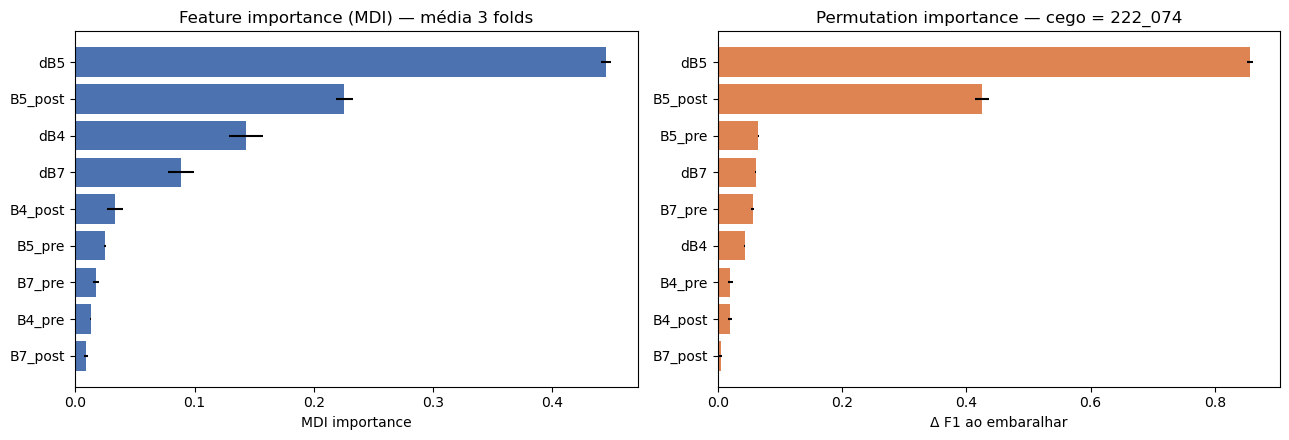

In [10]:
# --- Importância média via MDI -------------------------------------------
fi_stack = np.stack([r["feature_imp"] for r in loso_results])  # (3, 9)
fi_mean  = fi_stack.mean(axis=0)
fi_std   = fi_stack.std(axis=0)

order = np.argsort(fi_mean)[::-1]

print("Feature importance (MDI) — média ± desvio entre 3 folds, em ordem decrescente:")
for idx in order:
    print(f"  {FEATURE_NAMES[idx]:<10}: {fi_mean[idx]:.4f} ± {fi_std[idx]:.4f}")

# --- Permutation importance no fold mais difícil --------------------------
worst = min(loso_results, key=lambda r: r["rf_metrics"]["F1"])
log.info("\nPermutation importance — fold cego = %s (F1 = %.4f)",
         worst["blind_tag"], worst["rf_metrics"]["F1"])

# Em uma sub-amostra do treino para ser viável computacionalmente
sub_n = min(20_000, len(worst["y_train"]))
rng = np.random.default_rng(RNG_SEED)
sub = rng.choice(len(worst["y_train"]), size=sub_n, replace=False)

perm = permutation_importance(
    worst["rf_final"],
    worst["X_train"][sub],
    worst["y_train"][sub],
    n_repeats=5,
    random_state=RNG_SEED,
    scoring="f1",
    n_jobs=-1,
)

order_perm = np.argsort(perm.importances_mean)[::-1]
print("\nPermutation importance (Δ F1 ao embaralhar a feature):")
for idx in order_perm:
    print(f"  {FEATURE_NAMES[idx]:<10}: {perm.importances_mean[idx]:+.4f} ± {perm.importances_std[idx]:.4f}")

# --- Plot lado a lado -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(np.arange(N_FEATURES), fi_mean[order][::-1],
             xerr=fi_std[order][::-1], color="#4c72b0")
axes[0].set_yticks(np.arange(N_FEATURES))
axes[0].set_yticklabels([FEATURE_NAMES[i] for i in order[::-1]])
axes[0].set_xlabel("MDI importance")
axes[0].set_title("Feature importance (MDI) — média 3 folds")

axes[1].barh(np.arange(N_FEATURES),
             perm.importances_mean[order_perm][::-1],
             xerr=perm.importances_std[order_perm][::-1],
             color="#dd8452")
axes[1].set_yticks(np.arange(N_FEATURES))
axes[1].set_yticklabels([FEATURE_NAMES[i] for i in order_perm[::-1]])
axes[1].set_xlabel("Δ F1 ao embaralhar")
axes[1].set_title(f"Permutation importance — cego = {worst['blind_tag']}")

plt.tight_layout(); plt.show()

## 10. Diagnósticos visuais por fold

Matriz de confusão e curva ROC para cada um dos três folds LOSO. Útil para
ver onde o modelo erra em cada cena: muito FN (subestima) ou muito FP
(superestima)?

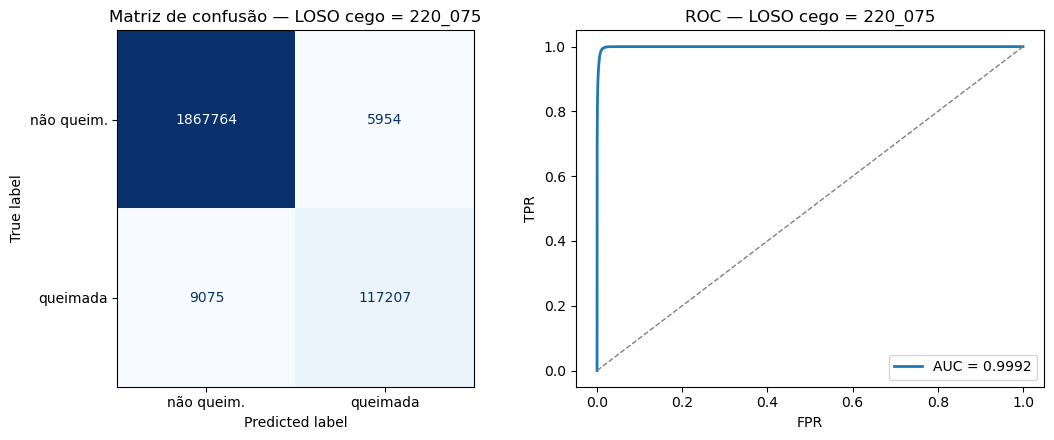

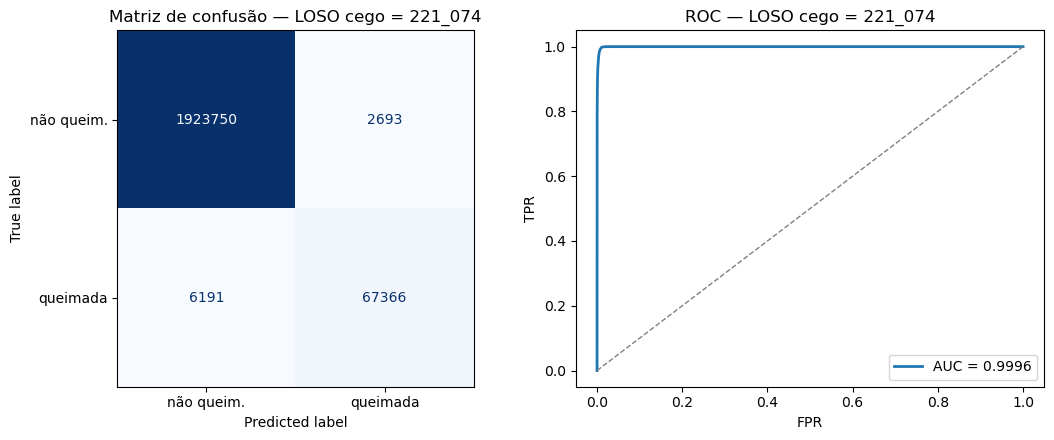

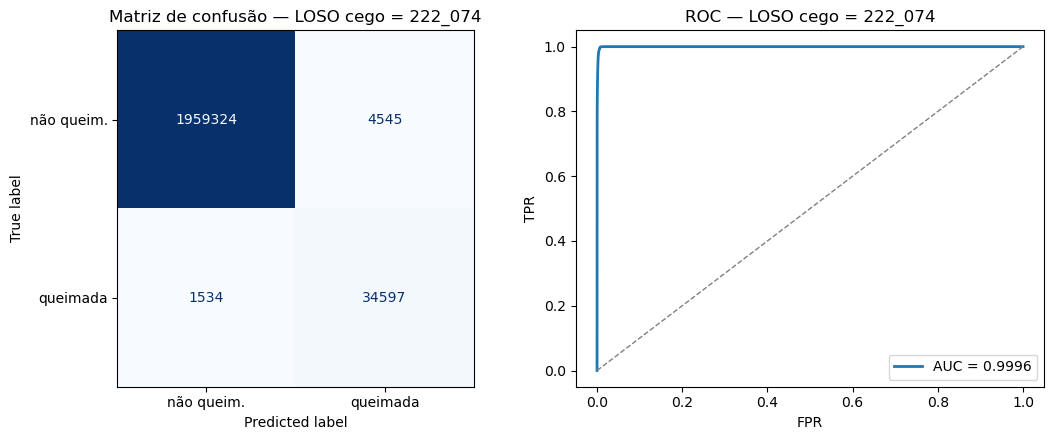

In [11]:
for r in loso_results:
    plot_diagnostics(
        r["y_blind"], r["pred_blind"], r["proba_blind"],
        panel_title=f"LOSO cego = {r['blind_tag']}",
    )

## 11. Modelo e protocolo experimental — recapitulação

### O que está implementado

**Configuração (Seção 2).** As três cenas (`220_075`, `221_074`, `222_074`) descritas com os caminhos completos para as 6 bandas (B4/B5/B7 × pré/pós), as 2 máscaras (NBR e NDVI) e o `dif_nbr_pre_pos.tif` reservado *só* para o baseline.

**I/O raster (Seção 3).** `warp_continuous` (bilinear) para bandas e dNBR; `warp_categorical` (nearest neighbor) para máscaras — evita os 0,5 que bilinear introduziria em rótulos binários.

**Construção do dataset (Seção 4).** Para cada cena: lê tudo, alinha ao grid da máscara NBR, monta o cubo `(H, W, 9)` na ordem fixa de `FEATURE_NAMES`, calcula a interseção `mask_nbr ∧ mask_ndvi` como ground truth, vetoriza, descarta inválidos e subamostra estratificado para no máximo **2 milhões de pixels por cena** (controla a memória total — três cenas inteiras seriam ~4 GB de features).

**Loop LOSO (Seção 7).** Três folds. Em cada um: junta as duas cenas de treino com `groups` por cena, subamostra **50 mil pixels balanceados** (25 k por cena, mantendo proporção de classes), roda `GridSearchCV` sobre 36 combinações com `GroupKFold(n_splits=2)` no tuning interno — ou seja, **o tuning também é avaliado entre cenas**, não dentro da cena. Refita com `oob_score=True`, infere na cena cega em chunks de 500 k, calcula métricas e dois baselines: `dNBR > 0,065` (real) e `dNBR > 0,27` (Key & Benson, referência da literatura).

**Agregação (Seção 8).** Tabela por fold + resumo agregado (média ± desvio) RF × baseline 0,065 × baseline 0,27. O desvio entre folds vira o sinal mais informativo: alto desvio = sensibilidade ao domínio; baixo desvio com F1 alto continua suspeito.

**Importância (Seção 9).** MDI média entre folds + `permutation_importance` no fold com pior F1 (com `n_repeats=5` em uma sub-amostra de 20 k pixels para ser viável). Plotadas lado a lado. Se uma feature dominar — especialmente `B7_post` ou `dB5/dB7` — o vazamento residual ficou alto.

**Diagnósticos (Seção 10).** Matriz de confusão e ROC para cada fold.

### Mudanças importantes em relação ao v1

- **`max_features` voltou** para o `GridSearch` — agora faz sentido, com 9 features.
- **`GroupKFold` no lugar de `StratifiedKFold`** — antes a CV vazava entre pixels da mesma cena.
- **Subamostragem dentro de cada cena**, não no pool global — cenas grandes não dominam mais o treino.
- **Lista única `loso_results`** carrega tudo o que cada fold produziu — fácil acessar `loso_results[i]["rf_final"]` se quiser inspecionar uma das árvores depois.


## 12. Análise dos resultados obtidos

### Os números

**Métricas LOSO por fold:**

| Cena cega | F1 | κ | AUC | Acc | Prec | Rec | `max_depth` ótimo |
|---|---|---|---|---|---|---|---|
| `220_075` | 0.9397 | 0.9357 | 0.9992 | 0.9925 | 0.9517 | 0.9281 | None |
| `221_074` | 0.9381 | 0.9358 | 0.9996 | 0.9956 | 0.9616 | 0.9158 | 25 |
| `222_074` | 0.9192 | 0.9177 | 0.9996 | 0.9970 | 0.8839 | 0.9575 | 15 |

**Agregado (média ± σ entre 3 folds):**

| Métrica | Baseline 0,065 | Baseline 0,27 | **Random Forest** |
|---|---|---|---|
| F1 | 0.8347 ± 0.0567 | 0.1857 ± 0.0218 | **0.9324 ± 0.0093** |
| κ | 0.8280 ± 0.0558 | 0.1799 ± 0.0235 | **0.9298 ± 0.0085** |
| Recall | 1.0000 ± 0.0000 | 0.1026 ± 0.0134 | 0.9338 ± 0.0175 |
| Precision | 0.7203 ± 0.0816 | 0.9951 ± 0.0051 | 0.9324 ± 0.0345 |
| Accuracy | 0.9868 ± 0.0018 | 0.9645 ± 0.0169 | 0.9950 ± 0.0019 |
| ROC-AUC | — | — | **0.9995 ± 0.0002** |

CV interna entre cenas (`GroupKFold` no tuning): F1 médio entre **0,896 e 0,927**. OOB no refit: **~0,995**. Tudo razoavelmente consistente.

Proporção de queimada por cena: `220_075` = 6,31% · `221_074` = 3,68% · `222_074` = **1,81%** (a mais difícil, e justamente a com pior F1).

### O experimento agora é honesto

Saímos de **F1 = κ = AUC = 1.0000** (v1, claramente colapsado) para **F1 = 0,932 ± 0,009** (v2). Esse é um número *realista* em sensoriamento remoto: o modelo erra ~6,7% das queimadas e tem ~6,7% de falsos positivos. A variação entre folds (σ ≈ 0,01) é pequena mas existe — o modelo é sensivelmente afetado pela mudança de cena, exatamente o esperado.

Mais importante: **a comparação contra o baseline agora faz sentido**. O RF vence o baseline `dNBR > 0,065` em **~10 pontos de F1 e ~10 pontos de κ**. Se o modelo só estivesse memorizando o threshold gerador, venceria por margem irrisória ou empataria. Os 10 pontos vêm da capacidade do RF de capturar pixels onde o threshold único da regra geradora ainda erra (ruído de borda, mistura sub-pixel, transições) — esse é o tipo de ganho que justifica usar um classificador.

O **paradoxo do baseline** (Precision 0,72 / Recall 1,00) também é coerente agora: como a interseção `NBR ∧ NDVI` é mais restrita que apenas `NBR`, todo pixel queimado segundo a interseção também tem `dNBR > 0,065` (recall 100% do baseline), mas há pixels com `dNBR > 0,065` que falham na concordância NDVI (precisão cai para ~72%).

### O ponto frágil: a feature `dB5` carrega o modelo

| Feature | MDI (média 3 folds) | Δ F1 ao embaralhar |
|---|---|---|
| **`dB5`** | **0.4448 ± 0.0040** | **+0.8567** |
| **`B5_post`** | **0.2257 ± 0.0070** | +0.4249 |
| `dB4` | 0.1434 ± 0.0141 | +0.0432 |
| `dB7` | 0.0886 ± 0.0112 | +0.0611 |
| `B5_pre` | 0.0247 ± 0.0008 | +0.0654 |
| `B7_pre` | 0.0176 ± 0.0027 | +0.0560 |
| `B4_post` | 0.0333 ± 0.0069 | +0.0192 |
| `B4_pre` | 0.0130 ± 0.0005 | +0.0205 |
| `B7_post` | 0.0090 ± 0.0013 | +0.0046 |

Embaralhar `dB5` no fold `222_074` derruba o F1 de **0,92 para ~0,06**. Em outras palavras, **quase todo o desempenho do RF vem de uma única feature** — as outras 8 contribuem com ajustes finos.

Isso tem uma explicação simples: como $\text{NBR} = (B_5 - B_7)/(B_5 + B_7)$, e em queimada $B_5$ (NIR) despenca mais do que $B_7$ (SWIR2) sobe em magnitude absoluta, `dB5 = B5_pre − B5_post` acaba sendo um proxy fortíssimo de `dNBR`. O RF essencialmente redescobriu uma versão "ruidosa" do `dNBR` usando `dB5`. O vazamento bandas → índice → máscara não foi eliminado, foi **atenuado**: agora o modelo precisa fazer uma transformação não-trivial para chegar lá, mas a transformação é simples o suficiente para que ele a encontre facilmente.

Sinal corroborante: **`B7_post` está praticamente irrelevante** (MDI 0,009, Δ F1 0,005), apesar de ser a banda mais próxima fisicamente da assinatura de fogo (cinza/carvão emite mais em SWIR2). O motivo provável é redundância — `dB5` já carrega informação suficiente, então o RF não precisa de `B7_post`.

### Como interpretar isso na prática

Três leituras coexistem:

> **Leitura otimista.** O pipeline funciona, o RF generaliza entre cenas (variação pequena mas presente), supera baselines, e os hiperparâmetros vencedores (`max_depth` indo de `None` → `25` → `15` conforme o fold) mostram que o `GridSearch` fez seu trabalho — em folds mais difíceis ele escolhe modelos mais regularizados.

> **Leitura cética.** O experimento ainda mede, em grande parte, a capacidade do RF de encontrar uma feature derivada (`dB5`) que aproxima a regra geradora da máscara. Os 10 pontos de F1 acima do baseline `dNBR > 0,065` vêm do RF combinar `dB5` com algumas outras bandas para capturar os ~7% de pixels onde a regra do gerador e a regra `dB5 > X` discordam. É um ganho real, mas o problema fundamental — máscara sintética derivada das próprias features — não foi resolvido.

> **Leitura comparativa.** Se o objetivo é parear com um experimento RBF-SVM nas mesmas condições, este setup oferece uma comparação justa: features iguais, máscara igual, protocolo igual (LOSO). Quem vencer agora vence pela escolha de classificador, não pela exploração da estrutura sintética da máscara. Esse era o objetivo declarado.